# Siamese Networks: Image Similarity Search and Company Face Verification

**Ready-to-run Google Colab notebook**  
This notebook implements two connected experiments:

1. An image-similarity search engine on the **Totally-Looks-Like (TLL)** dataset, trained and evaluated separately with **Contrastive Loss** and **Triplet Loss**.
2. An open-set face system for a small company that first rejects an unregistered face, then identifies a registered employee, and returns the **top 5 employees** with calibrated match probabilities.

The notebook downloads both datasets automatically, produces quantitative metrics and visual retrieval examples, measures inference time, and writes a report populated with the actual results.

> **Colab setup:** choose **Runtime → Change runtime type → T4 GPU**, then **Run all**. Start with `QUICK_RUN=True`; use `False` for final results.


## Experimental design

The shared encoder maps an image to an L2-normalized embedding $f(x)\in\mathbb{R}^D$.

**Contrastive loss** for pair label $y\in\{0,1\}$ and Euclidean distance $d$:

$$L_c=y d^2+(1-y)\max(0,m-d)^2.$$

**Triplet loss** for anchor $a$, positive $p$, negative $n$:

$$L_t=\max\left(\lVert f(a)-f(p)\rVert_2^2-\lVert f(a)-f(n)\rVert_2^2+\alpha,0\right).$$

Fair comparison rules:

- identical MobileNetV3-Small encoder architecture and ImageNet initialization;
- identical pair-disjoint TLL split, image resolution, augmentation, optimizer, batch size, and epoch count;
- retrieval evaluated by Recall@K, MRR, median positive rank, ROC-AUC, average precision, and embedding separation;
- training time, parameters, loss curves, and epoch time reported separately.

TLL contains human-selected pairs; its similarity may depend on pose, shape, semantics, humor, or cultural context. It is therefore harder than ordinary class matching.


In [1]:
# Install only packages that may be missing in Colab. PyTorch is preinstalled.
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "gdown>=5.1", "scikit-learn>=1.3", "seaborn>=0.13",
                "tqdm>=4.66", "tabulate>=0.9"], check=True)


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'gdown>=5.1', 'scikit-learn>=1.3', 'seaborn>=0.13', 'tqdm>=4.66', 'tabulate>=0.9'], returncode=0)

In [2]:
import os, random, time, math, copy, json, zipfile, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import MobileNet_V3_Small_Weights

from sklearn.datasets import fetch_lfw_people
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, average_precision_score, confusion_matrix
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
QUICK_RUN = True       # False = all 6,016 TLL pairs and longer training
IMAGE_SIZE = 160
EMBED_DIM = 128
BATCH_SIZE = 32
TLL_EPOCHS = 3 if QUICK_RUN else 10
FACE_EPOCHS = 4 if QUICK_RUN else 12
MAX_TLL_PAIRS = 1800 if QUICK_RUN else None
NUM_EMPLOYEES = 10
NUM_UNKNOWN_IDENTITIES = 5
NUM_WORKERS = 2

ROOT = Path("/content/siamese_project") if Path("/content").exists() else Path.cwd() / "siamese_project"
DATA_ROOT = ROOT / "data"
OUTPUT_ROOT = ROOT / "outputs"
MODEL_ROOT = ROOT / "models"
for p in (DATA_ROOT, OUTPUT_ROOT, MODEL_ROOT): p.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything()
print(f"Device: {DEVICE} | Quick run: {QUICK_RUN} | Output: {OUTPUT_ROOT}")


Device: cuda | Quick run: True | Output: /content/siamese_project/outputs


## Part A — Totally-Looks-Like image similarity search

The two archives below are the mirrors used by the official Keras TLL example. File order pairs each `left` image with the corresponding `right` image. The download requires no Kaggle token.


In [3]:
import gdown

TLL_ROOT = DATA_ROOT / "tll"
TLL_ROOT.mkdir(parents=True, exist_ok=True)
downloads = {
    "left.zip": "1jvkbTr_giSP3Ru8OwGNCg6B4PvVbcO34",
    "right.zip": "1EzBZUb_mh_Dp_FKD0P4XiYYSd0QBH5zW",
}
for filename, file_id in downloads.items():
    archive = TLL_ROOT / filename
    if not archive.exists():
        print("Downloading", filename)
        gdown.download(id=file_id, output=str(archive), quiet=False)
    target_name = filename.replace(".zip", "")
    if not any(p.is_dir() and p.name.lower() == target_name for p in TLL_ROOT.rglob("*")):
        with zipfile.ZipFile(archive) as zf:
            zf.extractall(TLL_ROOT)

EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
def find_image_dir(root, name):
    candidates = [p for p in root.rglob("*") if p.is_dir() and p.name.lower() == name.lower()]
    candidates = sorted(candidates, key=lambda p: len(list(p.rglob("*"))), reverse=True)
    if not candidates:
        raise FileNotFoundError(f"Could not locate extracted '{name}' directory under {root}")
    return candidates[0]

left_dir, right_dir = find_image_dir(TLL_ROOT, "left"), find_image_dir(TLL_ROOT, "right")
left_paths = sorted([p for p in left_dir.rglob("*") if p.suffix.lower() in EXTS])
right_paths = sorted([p for p in right_dir.rglob("*") if p.suffix.lower() in EXTS])
assert len(left_paths) == len(right_paths) and len(left_paths) > 100, (len(left_paths), len(right_paths))

pairs = list(zip(left_paths, right_paths))
rng = np.random.default_rng(SEED)
rng.shuffle(pairs)
if MAX_TLL_PAIRS:
    pairs = pairs[:MAX_TLL_PAIRS]

n = len(pairs)
n_train, n_val = int(.70*n), int(.15*n)
train_pairs = pairs[:n_train]
val_pairs = pairs[n_train:n_train+n_val]
test_pairs = pairs[n_train+n_val:]
print(f"TLL pairs used: {n:,} | train={len(train_pairs):,}, val={len(val_pairs):,}, test={len(test_pairs):,}")


Downloading...
From (original): https://drive.google.com/uc?id=1jvkbTr_giSP3Ru8OwGNCg6B4PvVbcO34
From (redirected): https://drive.google.com/uc?id=1jvkbTr_giSP3Ru8OwGNCg6B4PvVbcO34&confirm=t&uuid=559dc099-f1f9-49b6-a98d-74f03aeab755
To: /content/siamese_project/data/tll/left.zip
100%|██████████| 104M/104M [00:01<00:00, 52.5MB/s]


Downloading...
From (original): https://drive.google.com/uc?id=1EzBZUb_mh_Dp_FKD0P4XiYYSd0QBH5zW
From (redirected): https://drive.google.com/uc?id=1EzBZUb_mh_Dp_FKD0P4XiYYSd0QBH5zW&confirm=t&uuid=c30a4ef1-88e4-4a91-b6cd-ef7dafd9bfbf
To: /content/siamese_project/data/tll/right.zip
100%|██████████| 104M/104M [00:02<00:00, 50.7MB/s]


TLL pairs used: 1,800 | train=1,260, val=270, test=270


In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=.15, contrast=.15, saturation=.10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def open_rgb(path):
    return Image.open(path).convert("RGB")

class TLLPairDataset(Dataset):
    '''One positive and one deterministic/random negative pair per TLL pair.'''
    def __init__(self, pairs, transform, training=False):
        self.pairs, self.transform, self.training = list(pairs), transform, training
    def __len__(self): return 2 * len(self.pairs)
    def __getitem__(self, idx):
        i, positive = idx // 2, (idx % 2 == 0)
        a = self.pairs[i][0]
        if positive:
            b, y = self.pairs[i][1], 1.0
        else:
            if self.training:
                j = random.randrange(len(self.pairs)-1)
                if j >= i: j += 1
            else:
                j = (i + 1 + (i * 37) % (len(self.pairs)-1)) % len(self.pairs)
            b, y = self.pairs[j][1], 0.0
        return self.transform(open_rgb(a)), self.transform(open_rgb(b)), torch.tensor(y)

class TLLTripletDataset(Dataset):
    def __init__(self, pairs, transform, training=False):
        self.pairs, self.transform, self.training = list(pairs), transform, training
    def __len__(self): return len(self.pairs)
    def __getitem__(self, i):
        if self.training:
            j = random.randrange(len(self.pairs)-1)
            if j >= i: j += 1
        else:
            j = (i + 1 + (i * 37) % (len(self.pairs)-1)) % len(self.pairs)
        return (self.transform(open_rgb(self.pairs[i][0])),
                self.transform(open_rgb(self.pairs[i][1])),
                self.transform(open_rgb(self.pairs[j][1])))

def loader(ds, shuffle=False, batch_size=BATCH_SIZE):
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=="cuda"),
                      persistent_workers=(NUM_WORKERS > 0))

# Both objectives receive exactly the same three image roles. For contrastive
# training we apply one positive and one negative pair loss while reusing za.
pair_train_loader = loader(TLLTripletDataset(train_pairs, train_tf, True), True)
pair_val_loader = loader(TLLTripletDataset(val_pairs, eval_tf, False), False)
triplet_train_loader = loader(TLLTripletDataset(train_pairs, train_tf, True), True)
triplet_val_loader = loader(TLLTripletDataset(val_pairs, eval_tf, False), False)


In [5]:
class EmbeddingNet(nn.Module):
    def __init__(self, embedding_dim=EMBED_DIM, pretrained=True, trainable_blocks=3):
        super().__init__()
        weights = MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
        base = models.mobilenet_v3_small(weights=weights)
        feature_dim = base.classifier[0].in_features
        base.classifier = nn.Identity()
        self.backbone = base
        self.projector = nn.Sequential(
            nn.Linear(feature_dim, 256), nn.BatchNorm1d(256), nn.Hardswish(),
            nn.Dropout(.15), nn.Linear(256, embedding_dim)
        )
        for p in self.backbone.parameters(): p.requires_grad = False
        for block in self.backbone.features[-trainable_blocks:]:
            for p in block.parameters(): p.requires_grad = True
    def forward(self, x):
        z = self.projector(self.backbone(x))
        return F.normalize(z, p=2, dim=1)

class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0): super().__init__(); self.margin = margin
    def forward(self, z1, z2, y):
        d = F.pairwise_distance(z1, z2)
        return (y * d.pow(2) + (1-y) * F.relu(self.margin-d).pow(2)).mean()

def squared_triplet_loss(za, zp, zn, margin=.25):
    dap = (za-zp).pow(2).sum(1)
    dan = (za-zn).pow(2).sum(1)
    return F.relu(dap-dan+margin).mean()

def train_metric_model(kind, train_loader, val_loader, epochs, lr=2e-4):
    seed_everything(SEED)  # same initialization policy for each loss
    model = EmbeddingNet().to(DEVICE)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, epochs))
    criterion = ContrastiveLoss()
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type=="cuda"))
    history = {"train_loss":[], "val_loss":[], "epoch_seconds":[]}
    best_state, best_val = None, float("inf")
    total_start = time.perf_counter()

    for epoch in range(epochs):
        epoch_start = time.perf_counter(); model.train(); train_sum = train_n = 0
        for batch in tqdm(train_loader, leave=False, desc=f"{kind} {epoch+1}/{epochs}"):
            batch = [x.to(DEVICE, non_blocking=True) for x in batch]
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(DEVICE.type=="cuda")):
                if kind == "contrastive":
                    a, p, n = batch; za = model(a); bs = len(a)
                    loss = .5*(criterion(za, model(p), torch.ones(bs,device=DEVICE)) +
                               criterion(za, model(n), torch.zeros(bs,device=DEVICE)))
                else:
                    a, p, n = batch; loss = squared_triplet_loss(model(a), model(p), model(n))
                    bs = len(a)
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
            train_sum += loss.item()*bs; train_n += bs

        model.eval(); val_sum = val_n = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = [x.to(DEVICE, non_blocking=True) for x in batch]
                with torch.cuda.amp.autocast(enabled=(DEVICE.type=="cuda")):
                    if kind == "contrastive":
                        a, p, n = batch; za=model(a); bs=len(a)
                        loss=.5*(criterion(za,model(p),torch.ones(bs,device=DEVICE))+
                                 criterion(za,model(n),torch.zeros(bs,device=DEVICE)))
                    else:
                        a, p, n = batch; loss=squared_triplet_loss(model(a), model(p), model(n)); bs=len(a)
                val_sum += loss.item()*bs; val_n += bs
        scheduler.step()
        train_loss, val_loss = train_sum/train_n, val_sum/val_n
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["epoch_seconds"].append(time.perf_counter()-epoch_start)
        if val_loss < best_val:
            best_val, best_state = val_loss, copy.deepcopy(model.state_dict())
        print(f"{kind:11s} epoch {epoch+1:02d}: train={train_loss:.4f} val={val_loss:.4f}")
    model.load_state_dict(best_state)
    history["total_seconds"] = time.perf_counter()-total_start
    return model, history

contrastive_model, hist_con = train_metric_model("contrastive", pair_train_loader, pair_val_loader, TLL_EPOCHS)
triplet_model, hist_tri = train_metric_model("triplet", triplet_train_loader, triplet_val_loader, TLL_EPOCHS)

torch.save(contrastive_model.state_dict(), MODEL_ROOT/"tll_contrastive_encoder.pt")
torch.save(triplet_model.state_dict(), MODEL_ROOT/"tll_triplet_encoder.pt")


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 121MB/s]


contrastive 1/3:   0%|          | 0/40 [00:00<?, ?it/s]

contrastive epoch 01: train=0.6684 val=0.3949


contrastive 2/3:   0%|          | 0/40 [00:00<?, ?it/s]

...

triplet     epoch 01: train=0.1713 val=0.1531


triplet 2/3:   0%|          | 0/40 [00:00<?, ?it/s]

triplet     epoch 02: train=0.1396 val=0.1422


triplet 3/3:   0%|          | 0/40 [00:00<?, ?it/s]

triplet     epoch 03: train=0.1043 val=0.1442


In [6]:
@torch.inference_mode()
def embed_paths(model, paths, batch_size=64):
    model.eval(); vectors=[]
    for start in range(0, len(paths), batch_size):
        batch = torch.stack([eval_tf(open_rgb(p)) for p in paths[start:start+batch_size]]).to(DEVICE)
        vectors.append(model(batch).cpu())
    return torch.cat(vectors).numpy()

def threshold_metrics(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    i = np.argmax(tpr-fpr); threshold = float(thresholds[i])
    pred = (scores >= threshold).astype(int)
    return {
        "pair_roc_auc": roc_auc_score(y_true, scores),
        "pair_average_precision": average_precision_score(y_true, scores),
        "pair_accuracy": accuracy_score(y_true, pred),
        "pair_precision": precision_score(y_true, pred, zero_division=0),
        "pair_recall": recall_score(y_true, pred, zero_division=0),
        "pair_f1": f1_score(y_true, pred, zero_division=0),
        "pair_threshold": threshold,
    }, (fpr, tpr)

def evaluate_tll(model, name, history):
    left_test = [a for a,b in test_pairs]; right_test = [b for a,b in test_pairs]
    q = embed_paths(model, left_test); g = embed_paths(model, right_test)
    start = time.perf_counter(); sims = q @ g.T; search_seconds = time.perf_counter()-start
    order = np.argsort(-sims, axis=1)
    ranks = np.array([np.where(order[i] == i)[0][0]+1 for i in range(len(q))])
    pos = np.diag(sims); neg = sims[np.arange(len(q)), (np.arange(len(q))+1)%len(q)]
    y = np.r_[np.ones(len(pos)), np.zeros(len(neg))]
    scores = np.r_[pos, neg]
    pair_metrics, roc_data = threshold_metrics(y, scores)
    vals = history["val_loss"]
    target = min(vals) + .05*(vals[0]-min(vals))
    conv_epoch = next((i+1 for i,v in enumerate(vals) if v <= target), len(vals))
    row = {
        "loss": name, "recall_at_1": np.mean(ranks<=1), "recall_at_5": np.mean(ranks<=5),
        "recall_at_10": np.mean(ranks<=10), "mrr": np.mean(1/ranks),
        "median_positive_rank": np.median(ranks), "mean_positive_cosine": pos.mean(),
        "mean_negative_cosine": neg.mean(), "cosine_separation": pos.mean()-neg.mean(),
        "train_seconds": history["total_seconds"], "mean_epoch_seconds": np.mean(history["epoch_seconds"]),
        "convergence_epoch_95pct": conv_epoch, "search_ms_per_query": 1000*search_seconds/len(q),
        "trainable_parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
        **pair_metrics
    }
    return row, {"sims":sims, "order":order, "ranks":ranks, "roc":roc_data, "pos":pos, "neg":neg}

tll_rows, tll_details = [], {}
for name, model, hist in [("Contrastive", contrastive_model, hist_con), ("Triplet", triplet_model, hist_tri)]:
    row, details = evaluate_tll(model, name, hist)
    tll_rows.append(row); tll_details[name] = details
tll_results = pd.DataFrame(tll_rows).set_index("loss")
display(tll_results.round(4))
tll_results.to_csv(OUTPUT_ROOT/"tll_loss_comparison.csv")


,recall_at_1,recall_at_5,recall_at_10,mrr,median_positive_rank,mean_positive_cosine,mean_negative_cosine,cosine_separation,train_seconds,mean_epoch_seconds,convergence_epoch_95pct,search_ms_per_query,trainable_parameters,pair_roc_auc,pair_average_precision,pair_accuracy,pair_precision,pair_recall,pair_f1,pair_threshold
loss,,,,,,,,,,,,,,,,,,,,
Contrastive,0.1185,0.2407,0.3037,0.1842,29.0,0.7843,0.6807,0.1036,64.5625,21.4963,3,0.0167,825760,0.7725,0.7767,0.7056,0.6907,0.7444,0.7166,0.7371
Triplet,0.0852,0.1889,0.2926,0.1550,32.5,0.2900,0.1038,0.1863,52.3020,17.4152,2,0.0013,825760,0.7739,0.7771,0.7019,0.7339,0.6333,0.6799,0.2212


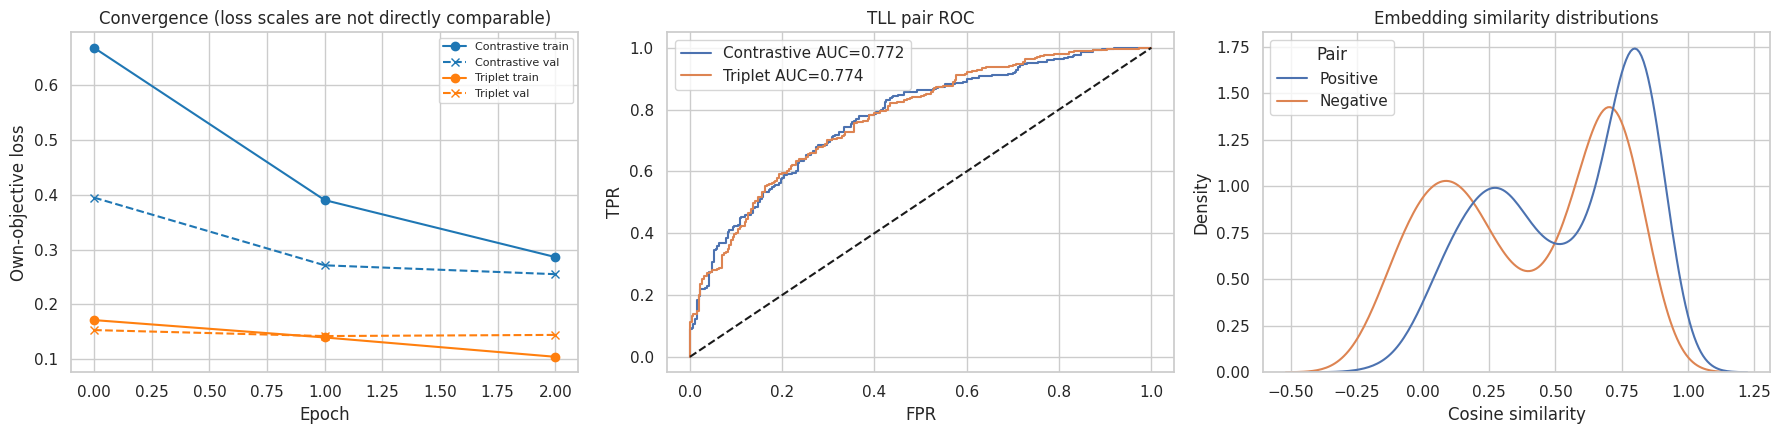

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for name, hist, color in [("Contrastive",hist_con,"tab:blue"),("Triplet",hist_tri,"tab:orange")]:
    axes[0].plot(hist["train_loss"], marker="o", label=f"{name} train", color=color)
    axes[0].plot(hist["val_loss"], marker="x", ls="--", label=f"{name} val", color=color)
axes[0].set(title="Convergence (loss scales are not directly comparable)", xlabel="Epoch", ylabel="Own-objective loss")
axes[0].legend(fontsize=8)
for name in ["Contrastive","Triplet"]:
    fpr,tpr=tll_details[name]["roc"]
    axes[1].plot(fpr,tpr,label=f"{name} AUC={tll_results.loc[name,'pair_roc_auc']:.3f}")
axes[1].plot([0,1],[0,1],"k--"); axes[1].set(title="TLL pair ROC", xlabel="FPR", ylabel="TPR"); axes[1].legend()
dist_df = pd.concat([pd.DataFrame({"Cosine similarity":np.r_[tll_details[n]["pos"], tll_details[n]["neg"]],
                                   "Pair": ["Positive"]*len(tll_details[n]["pos"])+["Negative"]*len(tll_details[n]["neg"]),
                                   "Loss":n}) for n in ["Contrastive","Triplet"]])
sns.kdeplot(data=dist_df, x="Cosine similarity", hue="Pair", common_norm=False, ax=axes[2])
axes[2].set_title("Embedding similarity distributions")
plt.tight_layout(); plt.savefig(OUTPUT_ROOT/"tll_comparison.png", dpi=180, bbox_inches="tight"); plt.show()

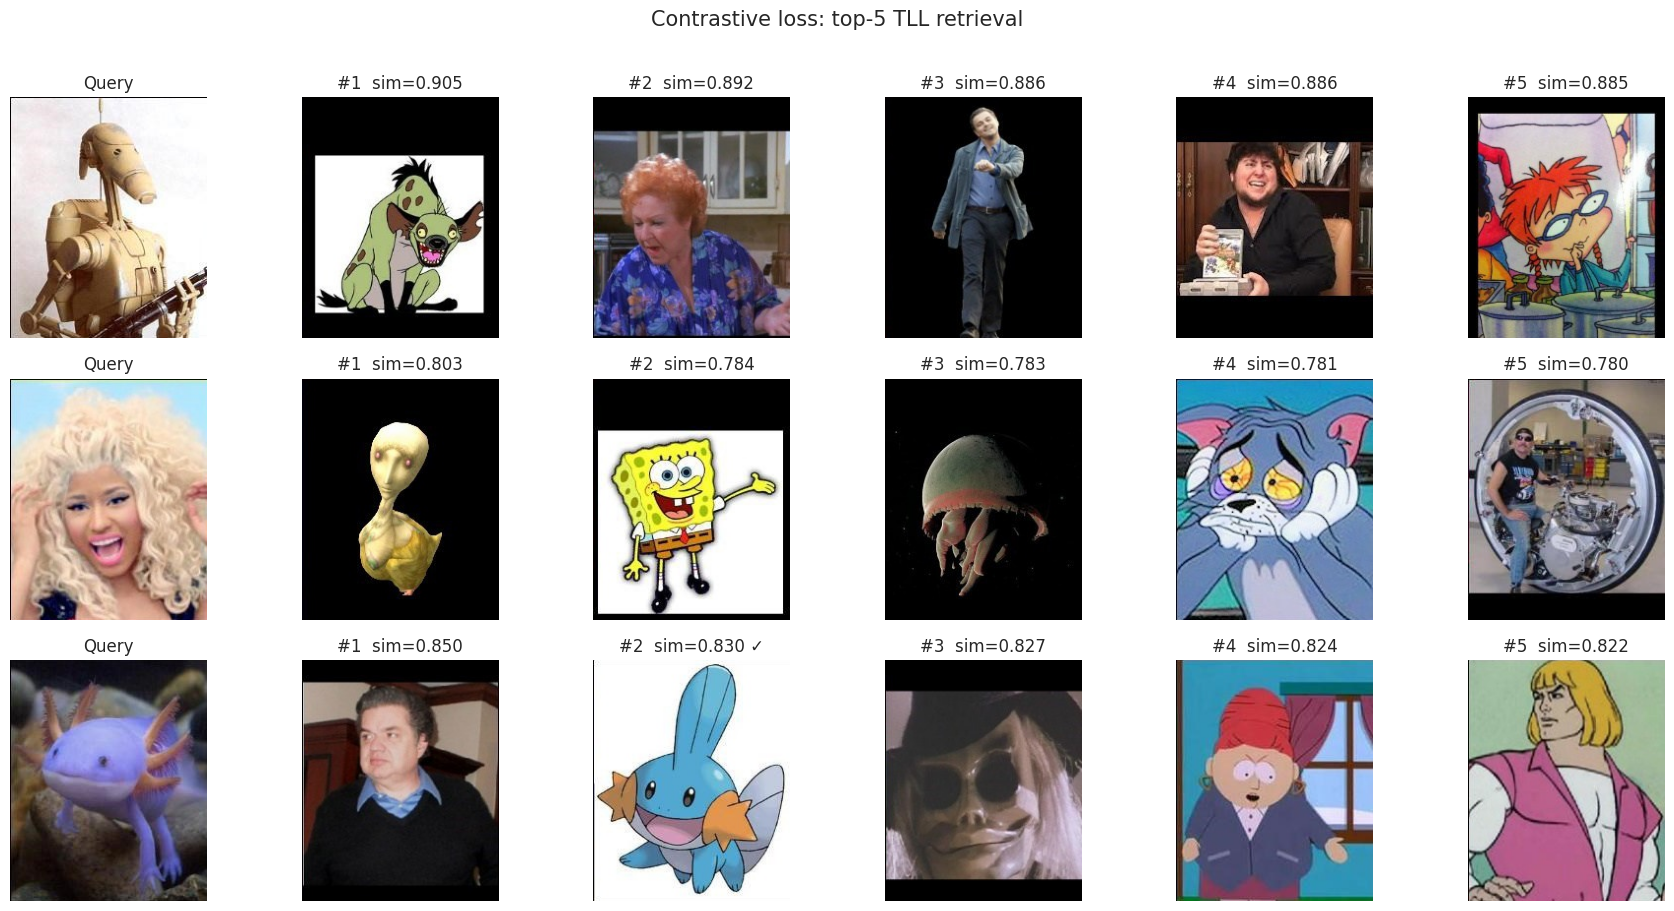

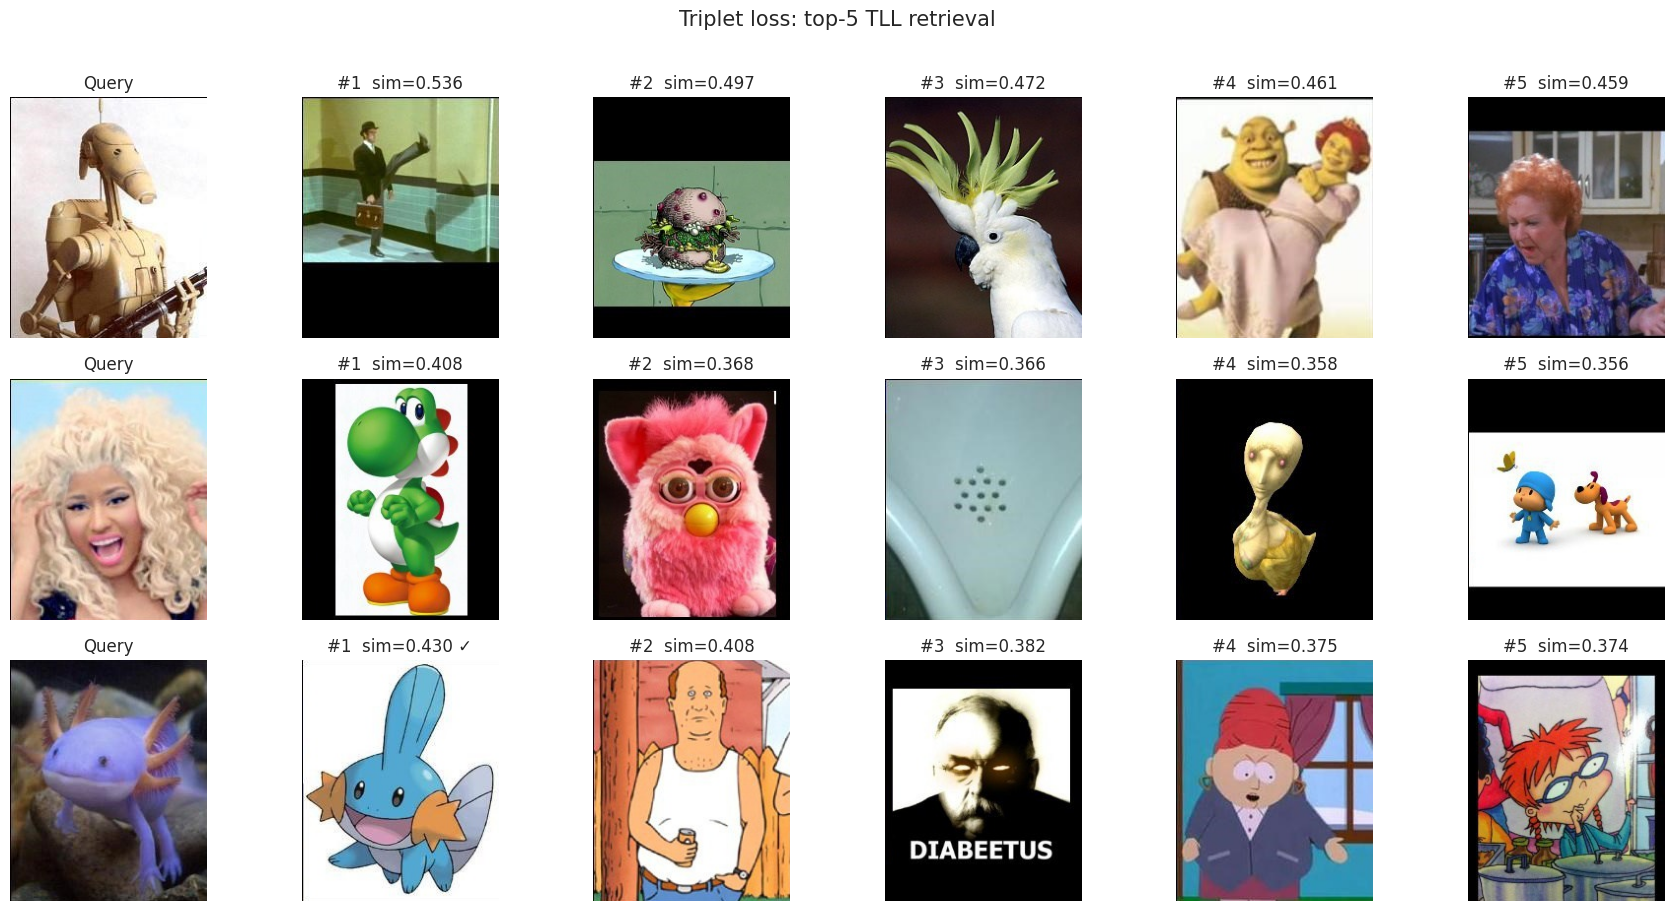

In [9]:
def show_tll_retrieval(model_name, query_indices=(0,1,2), k=5):
    details=tll_details[model_name]; left=[a for a,b in test_pairs]; right=[b for a,b in test_pairs]
    fig, axes=plt.subplots(len(query_indices), k+1, figsize=(3*(k+1),3*len(query_indices)))
    axes=np.atleast_2d(axes)
    for row,qi in enumerate(query_indices):
        axes[row,0].imshow(open_rgb(left[qi])); axes[row,0].set_title("Query")
        for c,gi in enumerate(details["order"][qi,:k],1):
            axes[row,c].imshow(open_rgb(right[gi]))
            correct=" ✓" if gi==qi else ""
            axes[row,c].set_title(f"#{c}  sim={details['sims'][qi,gi]:.3f}{correct}")
        for ax in axes[row]: ax.axis("off")
    fig.suptitle(f"{model_name} loss: top-{k} TLL retrieval", y=1.01, fontsize=15)
    plt.tight_layout(); plt.savefig(OUTPUT_ROOT/f"tll_retrieval_{model_name.lower()}.png", dpi=160, bbox_inches="tight"); plt.show()

show_tll_retrieval("Contrastive")
show_tll_retrieval("Triplet")


### How to interpret Part A

- **Embedding quality:** larger positive-minus-negative cosine separation and a cleaner distribution gap indicate a more discriminative space.
- **Retrieval accuracy:** Recall@1/5/10 and MRR directly measure whether the human-selected mate is ranked early. ROC-AUC instead tests pair discrimination; the two are related but not identical.
- **Convergence:** compare validation curves, epoch-to-95%-of-best, and wall time. Do not compare raw loss magnitudes across different objectives.
- **Complexity:** both methods have the same parameters and inference cost. In this controlled notebook both receive the same anchor/positive/negative batch and therefore use three encoder passes; the contrastive objective applies two pair terms while reusing the anchor. A standalone contrastive pair needs two branches and a triplet needs three. Exact brute-force retrieval is $O(ND)$ per query and stores $O(ND)$ gallery values.


## Part B — Open-set employee face verification and identification

Labeled Faces in the Wild (LFW) is downloaded automatically by scikit-learn. Ten identities simulate registered employees and five disjoint identities simulate visitors/unregistered people.

For each registered identity, images are divided into **training**, **validation**, **gallery/enrollment**, and **test-query** subsets. Unknown identities are never used to train the encoder. A validation set—not the test set—selects the acceptance threshold and fits a logistic calibration model.

The decision pipeline is:

1. embed query once;
2. compare with one normalized centroid per registered employee;
3. reject if the best similarity is below the validation-selected threshold;
4. otherwise identify the best employee;
5. always return the five highest-scoring employees.


In [10]:
lfw = fetch_lfw_people(data_home=str(DATA_ROOT/"lfw"), min_faces_per_person=20,
                       resize=0.7, color=True, download_if_missing=True)
face_images = lfw.images.astype("float32")
if face_images.max() > 1.5: face_images /= 255.0
face_labels = lfw.target.astype(int)
face_names = np.asarray(lfw.target_names)

counts = pd.Series(face_labels).value_counts().sort_values(ascending=False)
chosen = counts.index[:NUM_EMPLOYEES+NUM_UNKNOWN_IDENTITIES].to_numpy()
employee_ids = chosen[:NUM_EMPLOYEES]
unknown_ids = chosen[NUM_EMPLOYEES:]

splits = {k:[] for k in ["train","val_known","gallery","test_known","val_unknown","test_unknown"]}
rng = np.random.default_rng(SEED)
for identity in employee_ids:
    idx=np.where(face_labels==identity)[0]; rng.shuffle(idx)
    # At least 20 images: 3 gallery, 3 validation, 4 test, remainder training.
    splits["gallery"].extend(idx[:3]); splits["val_known"].extend(idx[3:6]);
    splits["test_known"].extend(idx[6:10]); splits["train"].extend(idx[10:])
for identity in unknown_ids:
    idx=np.where(face_labels==identity)[0]; rng.shuffle(idx); cut=max(1,len(idx)//2)
    splits["val_unknown"].extend(idx[:cut]); splits["test_unknown"].extend(idx[cut:])
for k in splits: splits[k]=np.asarray(splits[k], dtype=int)

print("Registered employees:")
for i in employee_ids: print(f"  {i:3d}: {face_names[i]} ({counts[i]} images)")
print({k:len(v) for k,v in splits.items()})


Registered employees:
   14: George W Bush (530 images)
   10: Colin Powell (236 images)
   58: Tony Blair (144 images)
   12: Donald Rumsfeld (121 images)
   15: Gerhard Schroeder (109 images)
    5: Ariel Sharon (77 images)
   21: Hugo Chavez (71 images)
   35: Junichiro Koizumi (60 images)
   25: Jean Chretien (55 images)
   31: John Ashcroft (53 images)
{'train': 1356, 'val_known': 30, 'gallery': 30, 'test_known': 40, 'val_unknown': 122, 'test_unknown': 123}


In [11]:
face_train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)), transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(.12,.12,.08), transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])
face_eval_tf = eval_tf

def array_to_pil(arr):
    return Image.fromarray(np.clip(arr*255,0,255).astype(np.uint8)).convert("RGB")

class FaceTripletDataset(Dataset):
    def __init__(self, images, labels, indices, transform, samples_per_epoch=None):
        self.images,self.labels,self.indices,self.transform=images,labels,np.asarray(indices),transform
        self.by_label={y:self.indices[labels[self.indices]==y] for y in np.unique(labels[self.indices])}
        self.identities=list(self.by_label)
        self.samples_per_epoch=samples_per_epoch or max(400,len(self.indices)*3)
    def __len__(self): return self.samples_per_epoch
    def __getitem__(self, _):
        y=random.choice(self.identities); pos_pool=self.by_label[y]
        a,p=np.random.choice(pos_pool,2,replace=(len(pos_pool)<2))
        ny=random.choice([v for v in self.identities if v!=y]); n=random.choice(self.by_label[ny])
        return (self.transform(array_to_pil(self.images[a])),
                self.transform(array_to_pil(self.images[p])),
                self.transform(array_to_pil(self.images[n])))

face_train_ds=FaceTripletDataset(face_images,face_labels,splits["train"],face_train_tf,
                                 samples_per_epoch=600 if QUICK_RUN else 1800)
# Validation triplets use the registered validation identities.
face_val_ds=FaceTripletDataset(face_images,face_labels,splits["val_known"],face_eval_tf,
                               samples_per_epoch=200 if QUICK_RUN else 500)
face_train_loader=loader(face_train_ds,True)
face_val_loader=loader(face_val_ds,False)

face_model, face_hist = train_metric_model("triplet",face_train_loader,face_val_loader,FACE_EPOCHS,lr=2e-4)
torch.save(face_model.state_dict(),MODEL_ROOT/"company_face_encoder.pt")


triplet 1/4:   0%|          | 0/19 [00:00<?, ?it/s]

triplet     epoch 01: train=0.2466 val=0.2466


triplet 2/4:   0%|          | 0/19 [00:00<?, ?it/s]

triplet     epoch 02: train=0.1947 val=0.2528


triplet 3/4:   0%|          | 0/19 [00:00<?, ?it/s]

triplet     epoch 03: train=0.1538 val=0.3018


triplet 4/4:   0%|          | 0/19 [00:00<?, ?it/s]

triplet     epoch 04: train=0.1637 val=0.2334


In [12]:
@torch.inference_mode()
def embed_face_indices(model, indices, batch_size=64):
    model.eval(); out=[]
    for start in range(0,len(indices),batch_size):
        batch=torch.stack([face_eval_tf(array_to_pil(face_images[i])) for i in indices[start:start+batch_size]]).to(DEVICE)
        out.append(model(batch).cpu())
    return torch.cat(out).numpy()

gallery_idx=splits["gallery"]
gallery_z=embed_face_indices(face_model,gallery_idx)
employee_names=[face_names[i] for i in employee_ids]
centroids=[]
for identity in employee_ids:
    z=gallery_z[face_labels[gallery_idx]==identity].mean(0)
    centroids.append(z/np.linalg.norm(z))
centroids=np.stack(centroids)

def candidate_matrix(indices):
    z=embed_face_indices(face_model,indices)
    return z@centroids.T

# Validation calibration: every query-employee candidate is a binary pair.
val_indices=np.r_[splits["val_known"],splits["val_unknown"]]
val_sim=candidate_matrix(val_indices)
val_pair_y=np.zeros_like(val_sim,dtype=int)
id_to_col={identity:j for j,identity in enumerate(employee_ids)}
for r,idx in enumerate(val_indices):
    if face_labels[idx] in id_to_col: val_pair_y[r,id_to_col[face_labels[idx]]]=1
calibrator=LogisticRegression(class_weight="balanced",random_state=SEED).fit(val_sim.reshape(-1,1),val_pair_y.ravel())

# Open-set threshold: known validation queries are positive; unknown queries are negative.
val_open_y=np.isin(face_labels[val_indices],employee_ids).astype(int)
val_best=val_sim.max(1)
fpr_v,tpr_v,thr_v=roc_curve(val_open_y,val_best)
fnr_v=1-tpr_v; eer_i=np.nanargmin(np.abs(fpr_v-fnr_v))
FACE_THRESHOLD=float(thr_v[eer_i])
print(f"Validation-selected similarity threshold: {FACE_THRESHOLD:.4f}; validation EER≈{(fpr_v[eer_i]+fnr_v[eer_i])/2:.4f}")


Validation-selected similarity threshold: 0.6852; validation EER≈0.5661


,value
open_set_accuracy,0.4969
open_set_precision,0.2308
open_set_recall,0.4500
open_set_f1,0.3051
open_set_roc_auc,0.5057
far,0.4878
frr,0.5500
eer,0.5267
identification_top1,0.3000
identification_top5,0.8000


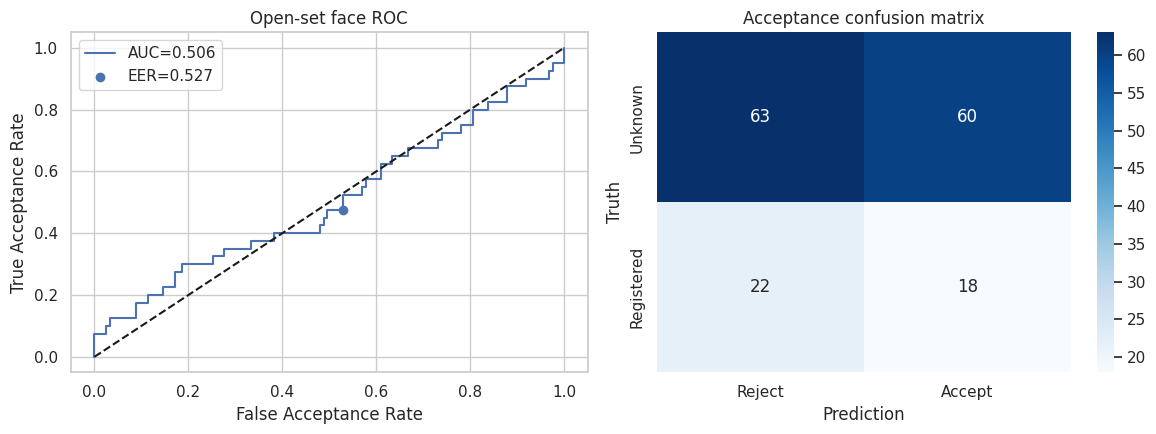

In [13]:
test_indices=np.r_[splits["test_known"],splits["test_unknown"]]
test_sim=candidate_matrix(test_indices)
test_best=test_sim.max(1); test_top1=test_sim.argmax(1)
test_open_y=np.isin(face_labels[test_indices],employee_ids).astype(int)
test_accept=(test_best>=FACE_THRESHOLD).astype(int)

fpr,tpr,thresholds=roc_curve(test_open_y,test_best); fnr=1-tpr
eer_i=np.nanargmin(np.abs(fpr-fnr)); eer=float((fpr[eer_i]+fnr[eer_i])/2)
known_mask=test_open_y==1
true_cols=np.array([id_to_col.get(face_labels[i],-1) for i in test_indices])
rank_order=np.argsort(-test_sim,axis=1)
true_ranks=np.array([np.where(rank_order[r]==true_cols[r])[0][0]+1 for r in np.where(known_mask)[0]])
system_correct=((test_open_y==0)&(test_accept==0)) | ((test_open_y==1)&(test_accept==1)&(test_top1==true_cols))

face_metrics={
    "open_set_accuracy":accuracy_score(test_open_y,test_accept),
    "open_set_precision":precision_score(test_open_y,test_accept,zero_division=0),
    "open_set_recall":recall_score(test_open_y,test_accept,zero_division=0),
    "open_set_f1":f1_score(test_open_y,test_accept,zero_division=0),
    "open_set_roc_auc":roc_auc_score(test_open_y,test_best),
    "far":float(np.mean(test_accept[test_open_y==0]==1)),
    "frr":float(np.mean(test_accept[test_open_y==1]==0)),
    "eer":eer,
    "identification_top1":float(np.mean(true_ranks<=1)),
    "identification_top5":float(np.mean(true_ranks<=5)),
    "end_to_end_correct_rate":float(np.mean(system_correct)),
    "threshold":FACE_THRESHOLD,
}
face_results=pd.DataFrame([face_metrics])
display(face_results.T.rename(columns={0:"value"}).round(4))
face_results.to_csv(OUTPUT_ROOT/"face_system_metrics.csv",index=False)

cm=confusion_matrix(test_open_y,test_accept)
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
axes[0].plot(fpr,tpr,label=f"AUC={face_metrics['open_set_roc_auc']:.3f}")
axes[0].plot([0,1],[0,1],"k--"); axes[0].scatter(fpr[eer_i],tpr[eer_i],label=f"EER={eer:.3f}")
axes[0].set(xlabel="False Acceptance Rate",ylabel="True Acceptance Rate",title="Open-set face ROC"); axes[0].legend()
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Reject","Accept"],yticklabels=["Unknown","Registered"],ax=axes[1])
axes[1].set(title="Acceptance confusion matrix",xlabel="Prediction",ylabel="Truth")
plt.tight_layout(); plt.savefig(OUTPUT_ROOT/"face_roc_confusion.png",dpi=180,bbox_inches="tight"); plt.show()


In [14]:
def rank_employee_candidates(similarities, k=5):
    order=np.argsort(-similarities)[:k]
    probs=calibrator.predict_proba(similarities[order,None])[:,1]
    return [{"rank":r+1,"employee":str(employee_names[j]),
             "similarity":float(similarities[j]),"match_probability":float(probs[r])}
            for r,j in enumerate(order)]

def verify_identify_array(image_array):
    '''Production-style API: reject/accept, identify, and return top-5 candidates.'''
    face_model.eval()
    x=face_eval_tf(array_to_pil(image_array)).unsqueeze(0).to(DEVICE)
    with torch.inference_mode(): z=face_model(x).cpu().numpy()[0]
    similarities=z@centroids.T
    top5=rank_employee_candidates(similarities,5)
    accepted=top5[0]["similarity"]>=FACE_THRESHOLD
    return {"registered":bool(accepted),
            "identified_employee":top5[0]["employee"] if accepted else "UNKNOWN / NOT REGISTERED",
            "decision_threshold":FACE_THRESHOLD,"top5":top5}

known_example=int(splits["test_known"][0]); unknown_example=int(splits["test_unknown"][0])
for title,idx in [("Registered query",known_example),("Unknown query",unknown_example)]:
    result=verify_identify_array(face_images[idx])
    print("\n",title,"| true identity:",face_names[face_labels[idx]])
    print(json.dumps(result,indent=2))



 Registered query | true identity: George W Bush
{
  "registered": true,
  "identified_employee": "Gerhard Schroeder",
  "decision_threshold": 0.6852287650108337,
  "top5": [
    {
      "rank": 1,
      "employee": "Gerhard Schroeder",
      "similarity": 0.7290014028549194,
      "match_probability": 0.6387159496609245
    },
    {
      "rank": 2,
      "employee": "Tony Blair",
      "similarity": 0.6051703691482544,
      "match_probability": 0.5234874375472844
    },
    {
      "rank": 3,
      "employee": "Colin Powell",
      "similarity": 0.5970250368118286,
      "match_probability": 0.5156757170541199
    },
    {
      "rank": 4,
      "employee": "George W Bush",
      "similarity": 0.5825105309486389,
      "match_probability": 0.5017391515035865
    },
    {
      "rank": 5,
      "employee": "Donald Rumsfeld",
      "similarity": 0.5475298166275024,
      "match_probability": 0.4681819962063757
    }
  ]
}

 Unknown query | true identity: Jacques Chirac
{
  "registere

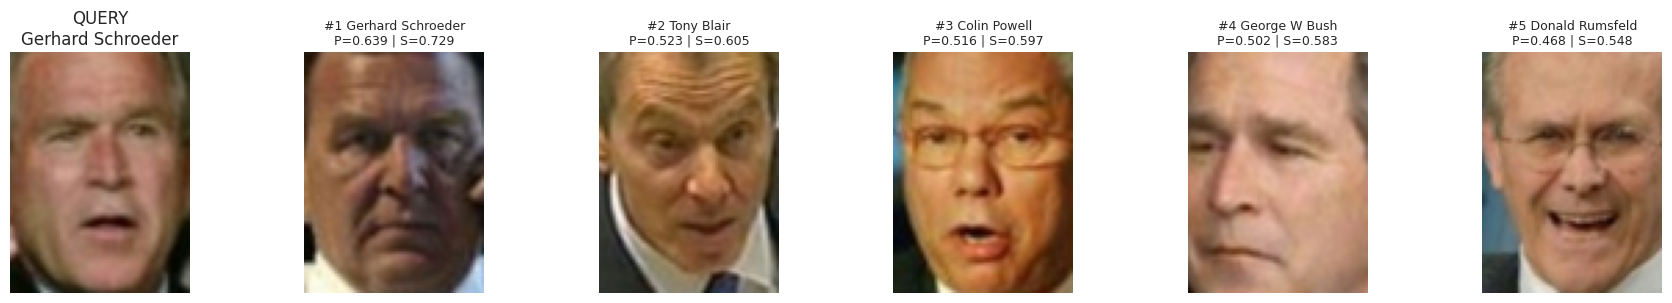

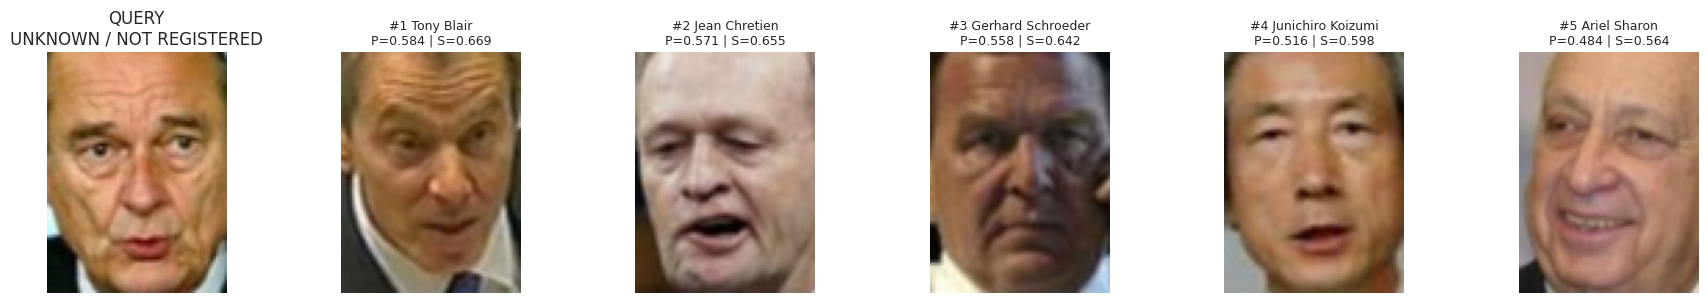

In [15]:
def show_face_ranking(idx,k=5):
    result=verify_identify_array(face_images[idx])
    fig,axes=plt.subplots(1,k+1,figsize=(3*(k+1),3.2))
    axes[0].imshow(face_images[idx]); axes[0].set_title("QUERY\n"+result["identified_employee"])
    for c,item in enumerate(result["top5"],1):
        employee_id=employee_ids[employee_names.index(item["employee"])]
        example_idx=gallery_idx[face_labels[gallery_idx]==employee_id][0]
        axes[c].imshow(face_images[example_idx])
        axes[c].set_title(f"#{c} {item['employee']}\nP={item['match_probability']:.3f} | S={item['similarity']:.3f}",fontsize=9)
    for ax in axes: ax.axis("off")
    plt.tight_layout(); plt.show()

show_face_ranking(known_example)
show_face_ranking(unknown_example)


In [16]:
# End-to-end latency: preprocessing + one query embedding + centroid search.
def timed_query(idx,repeats=1):
    samples=[]
    for _ in range(repeats):
        if DEVICE.type=="cuda": torch.cuda.synchronize()
        start=time.perf_counter(); _=verify_identify_array(face_images[idx])
        if DEVICE.type=="cuda": torch.cuda.synchronize()
        samples.append(1000*(time.perf_counter()-start))
    return samples

_ = timed_query(int(test_indices[0]),3)  # warm-up
latencies=[]
for idx in test_indices[:min(100,len(test_indices))]: latencies += timed_query(int(idx))
face_metrics.update({"inference_ms_mean":float(np.mean(latencies)),
                     "inference_ms_p50":float(np.percentile(latencies,50)),
                     "inference_ms_p95":float(np.percentile(latencies,95))})
face_results=pd.DataFrame([face_metrics]); face_results.to_csv(OUTPUT_ROOT/"face_system_metrics.csv",index=False)
print({k:round(face_metrics[k],3) for k in ["inference_ms_mean","inference_ms_p50","inference_ms_p95"]})


{'inference_ms_mean': 8.051, 'inference_ms_p50': 7.985, 'inference_ms_p95': 8.709}


## Optional — replace the simulated employees with company photos

Use consented enrollment images arranged as:

```text
employee_photos/
  Employee_A/ photo1.jpg photo2.jpg photo3.jpg
  Employee_B/ photo1.jpg photo2.jpg photo3.jpg
```

Align/crop one face per image before enrollment. The helper below creates employee centroids with the trained face encoder. In Colab you may upload a ZIP, extract it, and pass its folder to `build_company_gallery`. For a real deployment, retrain/fine-tune with the company training split and recalibrate the threshold with representative employees and non-employees.


In [17]:
@torch.inference_mode()
def embed_pil_list(model, pil_images):
    model.eval(); batch=torch.stack([face_eval_tf(im.convert("RGB")) for im in pil_images]).to(DEVICE)
    return model(batch).cpu().numpy()

def build_company_gallery(employee_root):
    root=Path(employee_root); names=[]; vectors=[]
    for folder in sorted([p for p in root.iterdir() if p.is_dir()]):
        paths=[p for p in folder.rglob("*") if p.suffix.lower() in EXTS]
        if len(paths)<2:
            print(f"Skipping {folder.name}: at least 2 enrollment photos are recommended"); continue
        z=embed_pil_list(face_model,[open_rgb(p) for p in paths]).mean(0); z/=np.linalg.norm(z)
        names.append(folder.name); vectors.append(z)
    if not vectors: raise ValueError("No valid employee folders found")
    return names,np.stack(vectors)

def verify_custom_query(query_path, company_names, company_centroids, threshold=FACE_THRESHOLD):
    z=embed_pil_list(face_model,[open_rgb(query_path)])[0]
    sims=z@company_centroids.T; order=np.argsort(-sims)[:5]
    probs=calibrator.predict_proba(sims[order,None])[:,1]
    top5=[{"rank":r+1,"employee":company_names[j],"similarity":float(sims[j]),"match_probability":float(probs[r])}
          for r,j in enumerate(order)]
    accepted=top5[0]["similarity"]>=threshold
    return {"registered":bool(accepted),"identified_employee":top5[0]["employee"] if accepted else "UNKNOWN / NOT REGISTERED","top5":top5}

# Example in Colab after uploading/extracting a ZIP:
# company_names, company_centroids = build_company_gallery("/content/employee_photos")
# verify_custom_query("/content/query.jpg", company_names, company_centroids)


## Automated report and conclusions

The next cell writes a report using the measured values, not invented results. It also records the limitations that should accompany any face-verification submission.


In [18]:
best_retrieval=tll_results["recall_at_1"].idxmax()
best_auc=tll_results["pair_roc_auc"].idxmax()
report=f'''# Experimental Report: Siamese Image Retrieval and Face Verification

## 1. Objective and implementation
An ImageNet-pretrained MobileNetV3-Small encoder with a {EMBED_DIM}-dimensional L2-normalized output was fine-tuned as a Siamese metric-learning model. The TLL experiment used {len(train_pairs)} training, {len(val_pairs)} validation, and {len(test_pairs)} pair-disjoint test pairs. Contrastive and triplet objectives used the same split and configuration. The face experiment simulated {NUM_EMPLOYEES} registered employees and {NUM_UNKNOWN_IDENTITIES} unknown identities from LFW.

## 2. TLL quantitative results
{tll_results.round(4).to_markdown()}

The highest Recall@1 was produced by **{best_retrieval} loss** ({tll_results.loc[best_retrieval,'recall_at_1']:.4f}); the highest pair ROC-AUC was produced by **{best_auc} loss** ({tll_results.loc[best_auc,'pair_roc_auc']:.4f}). Retrieval and pair classification measure different behavior: Recall@K ranks the true mate against the whole gallery, whereas ROC-AUC distinguishes balanced positive and sampled-negative pairs. Embedding separation is summarized by the positive-minus-negative cosine gap.

Contrastive learning directly constrains labeled pairs, but its result depends on the negative-pair ratio and margin. Triplet learning optimizes relative ranking, which aligns naturally with retrieval, but random triplets can become inactive once the margin is satisfied; hard or semi-hard negative mining can improve learning. A basic contrastive pair evaluates two encoder branches and a triplet evaluates three. For a fair controlled comparison here, both objectives receive the same anchor/positive/negative batch: contrastive applies positive and negative pair terms while reusing the anchor, so both perform three encoder passes. The extra distance arithmetic is O(D) and small compared with the encoder. Hard-negative mining can add substantial batch or index-search cost. Both trained encoders have identical inference complexity. Exact gallery search costs O(ND) time per query and O(ND) storage.

Raw loss magnitudes were not compared because the objectives have different scales. Convergence was evaluated using validation-curve shape, epoch-to-95%-of-best, epoch time, and total training time.

## 3. Face verification and identification results
{pd.DataFrame([face_metrics]).T.rename(columns={0:'value'}).round(4).to_markdown()}

The acceptance threshold ({FACE_THRESHOLD:.4f}) was selected on validation identities at the approximate equal-error operating point, then frozen before test evaluation. FAR is the fraction of unknown queries incorrectly accepted; FRR is the fraction of registered queries incorrectly rejected. Identification Top-1/Top-5 is computed only for registered test queries. `end_to_end_correct_rate` requires unknown rejection or, for a registered query, both acceptance and correct identity.

Each query is embedded once and compared with employee enrollment centroids. Candidate similarities are converted to display probabilities by a logistic model fitted only on validation candidate pairs. These are calibrated experimental scores, not guarantees of identity.

## 4. Challenges and limitations
1. TLL similarity is subjective and may reflect semantics or cultural associations beyond visual appearance. Random negatives can be too easy; stronger mining may change the comparison.
2. LFW is a public benchmark, not company operational data. Lighting, cameras, occlusion, aging, demographic balance, and employee count may shift FAR/FRR substantially.
3. The demonstration assumes a cropped/aligned single face. A deployed system needs face detection, alignment, image-quality checks, duplicate enrollment checks, and presentation-attack/liveness defenses.
4. Ten simulated employees produce wide uncertainty. Report confidence intervals and test many more unknown people before choosing a production threshold.
5. Nearest-neighbor probabilities are validation-calibrated and can be overconfident under distribution shift. Threshold and calibration require periodic revalidation.
6. Face embeddings are biometric data. Obtain informed consent, encrypt templates, minimize retention, restrict access, log use, provide a human fallback, and comply with applicable privacy and employment law.

## 5. Reproducibility
Seed={SEED}; image size={IMAGE_SIZE}; embedding dimension={EMBED_DIM}; TLL epochs={TLL_EPOCHS}; face epochs={FACE_EPOCHS}; device={DEVICE}. Quick-run mode was {QUICK_RUN}. Figures, CSV tables, and model state dictionaries were saved by the notebook.
'''
(OUTPUT_ROOT/"siamese_experimental_report.md").write_text(report,encoding="utf-8")
print(report)
print("\nSaved artifacts:")
for p in sorted(OUTPUT_ROOT.iterdir()): print(" -",p)


# Experimental Report: Siamese Image Retrieval and Face Verification

## 1. Objective and implementation
An ImageNet-pretrained MobileNetV3-Small encoder with a 128-dimensional L2-normalized output was fine-tuned as a Siamese metric-learning model. The TLL experiment used 1260 training, 270 validation, and 270 pair-disjoint test pairs. Contrastive and triplet objectives used the same split and configuration. The face experiment simulated 10 registered employees and 5 unknown identities from LFW.

## 2. TLL quantitative results
| loss        |   recall_at_1 |   recall_at_5 |   recall_at_10 |    mrr |   median_positive_rank |   mean_positive_cosine |   mean_negative_cosine |   cosine_separation |   train_seconds |   mean_epoch_seconds |   convergence_epoch_95pct |   search_ms_per_query |   trainable_parameters |   pair_roc_auc |   pair_average_precision |   pair_accuracy |   pair_precision |   pair_recall |   pair_f1 |   pair_threshold |
|:------------|--------------:|--------------:|---

## Final submission checklist

- For final reported numbers, set `QUICK_RUN=False`, use a GPU, restart the runtime, and run all cells.
- Keep the generated CSV files and figures with the report.
- State that LFW employees are a simulation; do not claim company deployment accuracy from LFW.
- If company images are available, create identity-disjoint training/validation/test subsets, retrain, recalibrate the threshold, and rerun every metric.
- For stronger TLL results, add semi-hard negative mining and multiple random seeds; report mean ± standard deviation.

### Dataset and method references

1. Rosenfeld, Solbach, and Tsotsos, [*Totally Looks Like—How Humans Compare, Compared to Machines*](https://arxiv.org/abs/1803.01485), ACCV 2018; [dataset page](https://sites.google.com/view/totally-looks-like-dataset).
2. Hadsell, Chopra, and LeCun, [*Dimensionality Reduction by Learning an Invariant Mapping*](http://yann.lecun.com/exdb/publis/pdf/hadsell-chopra-lecun-06.pdf), CVPR 2006.
3. Schroff, Kalenichenko, and Philbin, [*FaceNet: A Unified Embedding for Face Recognition and Clustering*](https://arxiv.org/abs/1503.03832), CVPR 2015.
4. Huang et al., [*Labeled Faces in the Wild: A Database for Studying Face Recognition in Unconstrained Environments*](http://vis-www.cs.umass.edu/lfw/), 2007; [scikit-learn loader documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_lfw_people.html).
